# Data Profiling 
This section assesses the dataset's structure, quality, and potential issues.

**Data Loading & Date Parsing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# load the csv file
df = pd.read_csv('../data/kenya.csv') 
# Add Country Column
df['Country'] = 'Ethiopia'
# create a dat from the year and DOY
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
#extracting a month from the year and the DOY
df['Month'] = df['Date'].dt.month
# Check the results
print(df[['YEAR', 'DOY',  'Month']].tail())



      YEAR  DOY  Month
4103  2026   86      3
4104  2026   87      3
4105  2026   88      3
4106  2026   89      3
4107  2026   90      3


**Summary Statistics & Missing-Value Report**

In [42]:
# Check how many rows and features columns we have
print("Data Shape:", df.shape) 
#  Handle NASA Sentinel Values
df.replace(-999, np.nan, inplace=True)
# Duplicate Check
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")


Data Shape: (4108, 15)
Total Duplicate Rows Found: 0


**Duplicate check**

0 duplicate rows were detected across all 4,108 observations.

Therefore, No data removal was required showing that each record in the Ethiopia dataset represents a unique observation.

In [15]:

# Generate the 5-number summary (count, mean, std, min, max)
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


**Statistical Interpretation of Climate Variables**

 A review of the central tendency, dispersion, and range of the Ethiopia climate dataset (2015–2026).
 
Temperature (T2M): The average temperature is about 16.07°C. It stays very consistent, usually staying within a small range. The highest it ever got was 21.53°C and the lowest was 10.03°C. Since the average and the middle value (median) are almost the same, the temperature data is very balanced.

Daily Temp Change (T2M_RANGE): There is a big difference between day and night temperatures. On average, the temperature swings by 12.97°C every day. On extreme days, it can swing by as much as 23.24°C

Rainfall (PRECTOTCORR): This is the comparably unbalanced data. While the average is 3.63 mm per day, most days have very little rain. However, the average is influenced by heavy storms, with maximum having 82.30 mm.

Humidity and Wind (RH2M & WS2M): The air is fairly moist, with an average humidity of 68.4%. The wind is generally calm, averaging about 1.98 m/s, though it can go up to 7.49 m/s.

Time Period: The dataset is 4,108 days of information. It covers from January 2015 to March 2026.

In [16]:
# Check for Missing Values
print("\n--- Missing Value Count ---")
print(df.isna().sum())
missing_values = df.isna().sum()
missing_pct = (missing_values / len(df)) * 100


--- Missing Value Count ---
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


The missing value analysis shows the Ethiopia dataset contains 0% null values across all columns.

What this means for the analysis: Since no columns exceed the 5% threshold. We do not need to fill any gaps. 

**Outlier Detection & Basic Cleaning**



In [18]:
#  Z-Score Calculation
target_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[target_cols].dropna()))

# Flagging outliers
outliers_count = (z_scores > 3).sum(axis=0)
print("Outlier counts per column (|Z| > 3):")
print(outliers_count)

Outlier counts per column (|Z| > 3):
[ 3  0 18 95 13  3  5]


**Outlier Detection**

In total we have 137 outliers across the given columns. 

It has been chosen to retain the 137 identified outliers because,

 In a climate dataset, extreme values represent important weather events like storms and heatwaves. Most of these outliers are in the Rainfall (PRECTOTCORR) column. This is expected because rain happens in sudden bursts, and these spikes are a real part of the average.

Out of 4,108 observations, these 137 outliers make up less than 0.5% of the data. Keeping them protects the natural variety of the climate record without hurting the accuracy of our trend analysis.

In [ ]:
# Handling Strategy
# Forward-fill for weather variables to maintain time-series continuity
df[target_cols] = df[target_cols].ffill()

# Export Cleaned Data and the data folder is in gitignore
df.to_csv('../data/ethiopia_clean.csv', index=False)

**Time Series Analysis**

***Monthly Temperature Trends (2015–2026)***

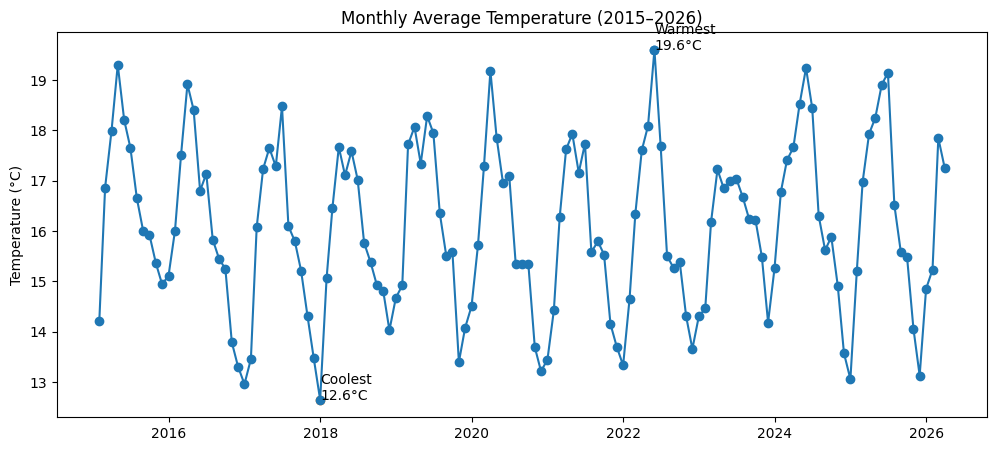

In [23]:
# Resample to monthly averages
monthly_temp = df.set_index('Date').resample('ME')['T2M'].mean().reset_index()

# Find warmest and coolest months
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], marker='o')

# Annotate
plt.scatter(warmest['Date'], warmest['T2M'])
plt.text(warmest['Date'], warmest['T2M'], f"Warmest\n{warmest['T2M']:.1f}°C")

plt.scatter(coolest['Date'], coolest['T2M'])
plt.text(coolest['Date'], coolest['T2M'], f"Coolest\n{coolest['T2M']:.1f}°C")

plt.title('Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.show()

The line chart shows how the temperature moves up and down in a steady every year. The average temperature usually stays between 13°C and 19°C. we can see that 2018 had the coolest month, while 2022 the warmest peak. Overall, the temperature is very consistent, repeating the same pattern every year.

**Monthly Total Precipitation**

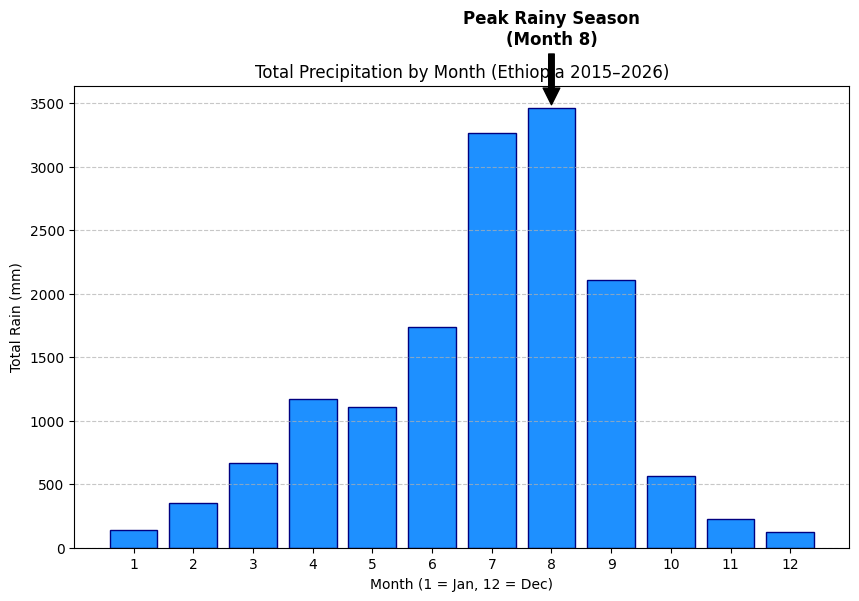

In [32]:
# 1. Group by Month (1-12) to get the total rain for that month across all years
seasonal_rain = df.groupby('Month')['PRECTOTCORR'].sum().reset_index()

# 2. Find the peak month for annotation
peak_val = seasonal_rain['PRECTOTCORR'].max()
peak_month_num = seasonal_rain.loc[seasonal_rain['PRECTOTCORR'].idxmax(), 'Month']

# 3. Plotting
plt.figure(figsize=(10, 6))
# We use seasonal_rain['Month'] as the X-axis so we get 12 clean bars
plt.bar(seasonal_rain['Month'], seasonal_rain['PRECTOTCORR'], color='dodgerblue', edgecolor='navy')

# 4. Annotation (Identifying the peak)
plt.annotate(f'Peak Rainy Season\n(Month {int(peak_month_num)})', 
             xy=(peak_month_num, peak_val), 
             xytext=(peak_month_num, peak_val + 500),
             ha='center',
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

plt.title('Total Precipitation by Month (Ethiopia 2015–2026)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Total Rain (mm)')
plt.xticks(range(1, 13)) # Show every month number
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart shows a clear bell shape, which shows the rainy season. Rainfall starts to increase in June and reaches its  peak in August (Month 8). After August, the rain drops off quickly as it moves into the dry season. This confirms that the middle of the year is the most critical time for water and agriculture in Ethiopia.

**Correlation & Relationship Analysis**

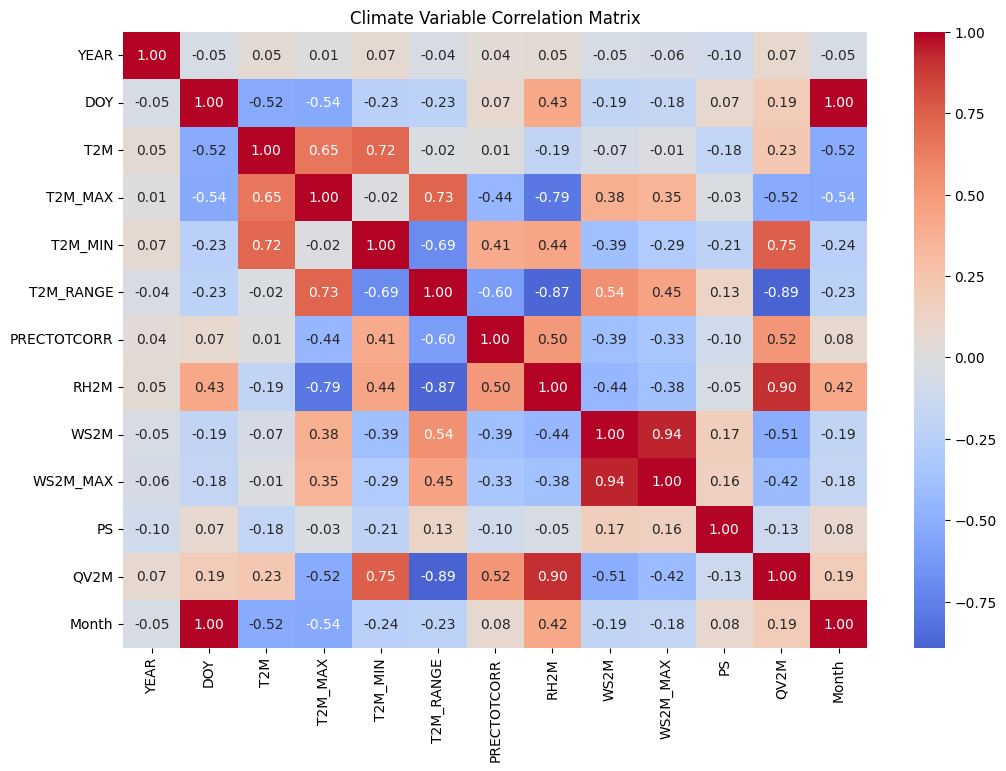

In [ ]:
# Heatmap of correlations
plt.figure(figsize=(12, 8))
# We only select numeric columns to avoid errors with the Date or Country strings
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Climate Variable Correlation Matrix')
plt.show()

Based on the heatmap, here are the three most significant relationships in the dataset:

Wind Speed (WS2M vs. WS2M_MAX): 0.94
This is a near-perfect positive correlation. It tells us that on days when the average wind speed is high, the maximum values are also very strong. 

Humidity & Water Vapor (RH2M vs. QV2M): 0.90
This strong positive correlation shows that as the actual weight of water vapor in the air (QV2M) increases, the relative humidity (RH2M) also rises significantly. 

Temperature Range vs. Humidity (T2M_RANGE vs. RH2M): -0.87
This is a very strong negative correlation (shown in deep blue). It suggests that on days with a very high temperature swing between day and night, the humidity is usually very low. 

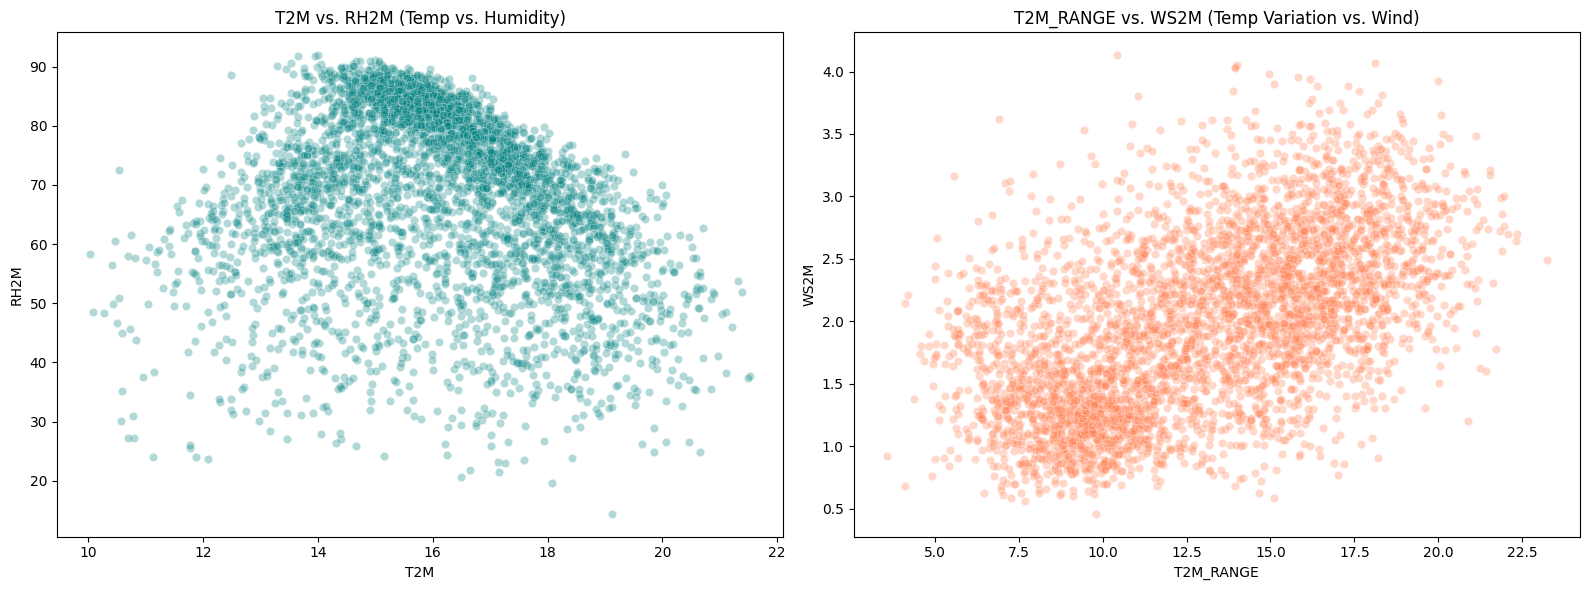

In [ ]:
# Scatter plots for specific relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs Relative Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('T2M vs. RH2M (Temp vs. Humidity)')

# Plot 2: Diurnal Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M (Temp Variation vs. Wind)')

plt.tight_layout()
plt.show()

Temperature vs. Humidity : This plot shows a generally downward slope. As the temperature (T2M) increases beyond 15°C, the relative humidity (RH2M) tends to decrease. 

Temp Range vs. Wind Speed (Right): This plot shows a slight upward trend. Days with a larger gap between daytime highs and nighttime lows (T2M_RANGE) often relate with higher wind speeds (WS2M). 

**Distribution Analysis**

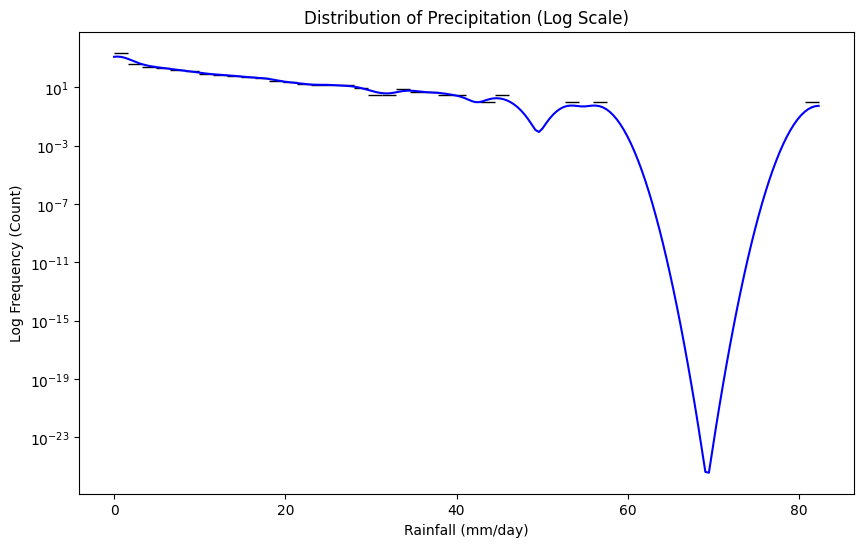

In [ ]:
#  Distribution of Rainfall
plt.figure(figsize=(10, 6))
# log_scale=(False, True) means the counts (Y-axis) are log-transformed
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='blue', log_scale=(False, True))

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Rainfall (mm/day)')
plt.ylabel('Log Frequency (Count)')
plt.show()

The histogram shows that rainfall in Ethiopia is heavily skewed. Most days have very little to no rain, which is why the line stays high on the left. By using a Log Scale, we can see the "long tail" of the data. This reveals that while they are rare, Ethiopia does experience massive storm events—some reaching over 80 mm in a single day. 

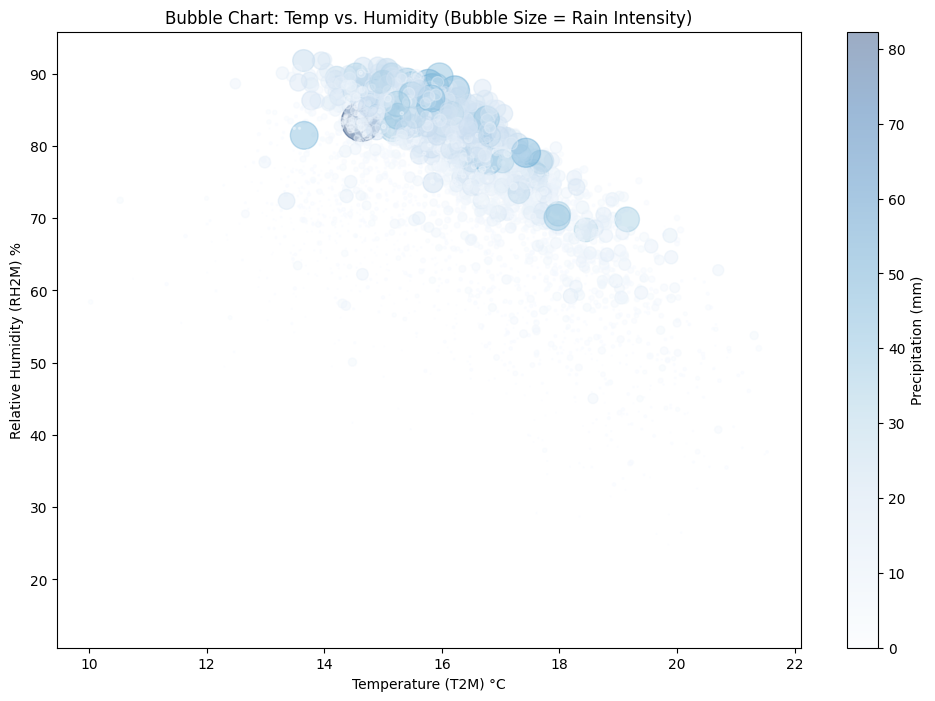

In [ ]:
# Bubble Chart: T2M vs. RH2M (Size = PRECTOTCORR)
plt.figure(figsize=(12, 8))

# We multiply PRECTOTCORR by 10 to make the bubbles large enough to see
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 10, 
            alpha=0.4, 
            c=df['PRECTOTCORR'], 
            cmap='Blues')

plt.colorbar(label='Precipitation (mm)')
plt.title('Bubble Chart: Temp vs. Humidity (Bubble Size = Rain Intensity)')
plt.xlabel('Temperature (T2M) °C')
plt.ylabel('Relative Humidity (RH2M) %')
plt.show()

This bubble chart brings everything together. It shows that the heaviest rainfall (the largest, darkest bubbles) almost always happens when Relative Humidity is high (above 70%) and Temperatures are moderate (between 14°C and 18°C). When it gets too hot and dry (bottom right), the bubbles disappear, meaning rain is very unlikely.